# Building Python Model
Building a simplified python model to measure solar irradiace of rooftops in Sandy Bay and Howrah. 

**Inputs**
- The 0.5 m surface model for each test area (from notebook 01)
- The hourly weather file for Hobart Ellerslie Road (GHI, DNI and DHI)
  
*We use the same surface models and weather file that went into SEBE, so any difference between the two results comes from the models and not the data.*


## 1. Read in the surface models

Reading in the 0.5 m surface model for each test area.

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

inpath = Path("/Users/lailamclennan/Documents/CODING/AT3/Inputs")
outpath = Path("/Users/lailamclennan/Documents/CODING/AT3/Outputs")

In [ ]:
west_dsm_path = inpath / "DSM" / "West_GDA2020.tif"   # Sandy Bay
east_dsm_path = inpath / "DSM" / "East_GDA2020.tif"   # Howrah

# West (Sandy Bay)
west_file = rasterio.open(west_dsm_path)
west_dsm = west_file.read(1)
west_profile = west_file.profile
west_file.close()

# East (Howrah)
east_file = rasterio.open(east_dsm_path)
east_dsm = east_file.read(1)
east_profile = east_file.profile
east_file.close()

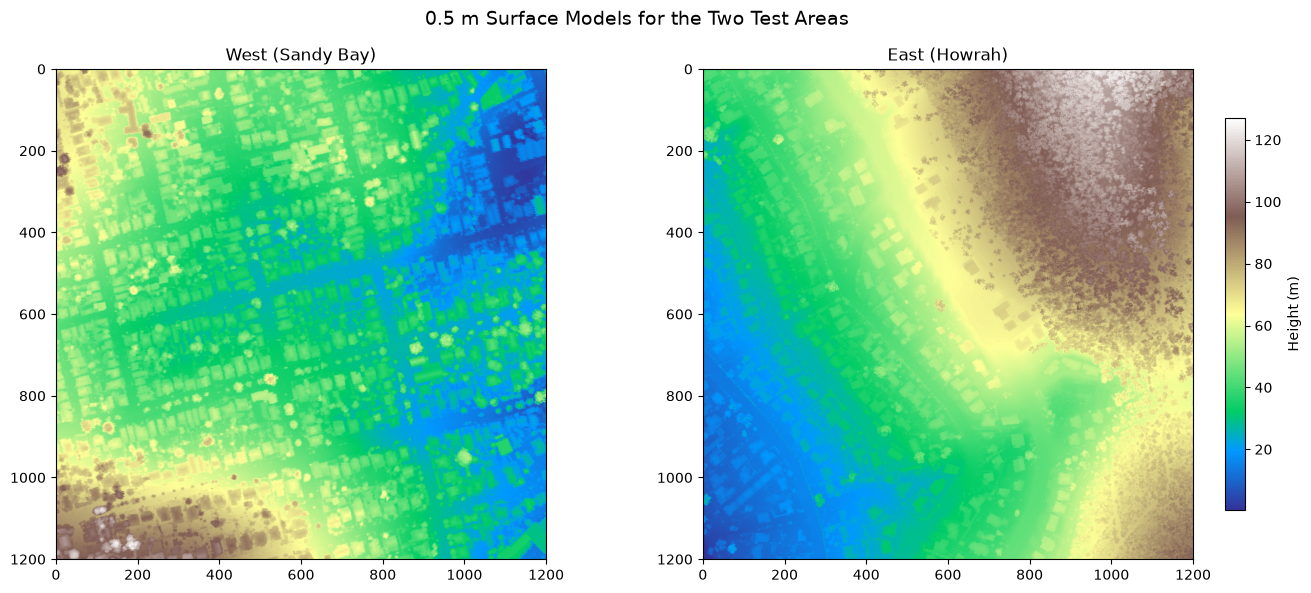

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# West (Sandy Bay)
west_plot = axes[0].imshow(west_dsm, cmap="terrain")
axes[0].set_title("West (Sandy Bay)")

# East (Howrah)
east_plot = axes[1].imshow(east_dsm, cmap="terrain")
axes[1].set_title("East (Howrah)")
fig.colorbar(east_plot, ax=axes[1], label="Height (m)", shrink=0.8)

fig.suptitle("0.5 m Surface Models for the Two Test Areas", fontsize=14)
plt.tight_layout()
# Save the figure so we can use it on the website
fig.savefig("images/dsm_test_areas.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Slope, Aspect and Roughness

In [ ]:
from osgeo import gdal

# Define the output file paths
west_slope_path = outpath / "West_slope.tif"
west_aspect_path = outpath / "West_aspect.tif"
east_slope_path = outpath / "East_slope.tif"
east_aspect_path = outpath / "East_aspect.tif"

# West (Sandy Bay)
# Slope comes out in degrees (0 is flat, 90 is vertical)
gdal.DEMProcessing(
    destName=str(west_slope_path),
    srcDS=str(west_dsm_path),
    processing="slope"
)

# Aspect comes out in degrees (0 is North, 90 is East, 180 is South, 270 is West)
gdal.DEMProcessing(
    destName=str(west_aspect_path),
    srcDS=str(west_dsm_path),
    processing="aspect"
)

# East (Howrah)
gdal.DEMProcessing(
    destName=str(east_slope_path),
    srcDS=str(east_dsm_path),
    processing="slope"
)

gdal.DEMProcessing(
    destName=str(east_aspect_path),
    srcDS=str(east_dsm_path),
    processing="aspect"
)

print("Slope and aspect files saved")

Slope and aspect files saved


In [26]:
# For Slope and aspect, we need to read the files in.
# Replace any NoData values (-9999) with 0.
# Convert the values from degrees to radians for use with numpy trig functions.

# West (Sandy Bay) slope
west_slope_file = rasterio.open(outpath / "West_slope.tif")     # Open the slope file
west_slope_degrees = west_slope_file.read(1)                    # Read the slope values into a numpy array
west_slope_file.close()                                         # Close the slope file

west_slope_degrees[west_slope_degrees == -9999] = 0             # Replace NoData values with 0
west_slope = np.radians(west_slope_degrees)                     # Convert slope values from degrees to radians

# West (Sandy Bay) aspect
west_aspect_file = rasterio.open(outpath / "West_aspect.tif")
west_aspect_degrees = west_aspect_file.read(1)
west_aspect_file.close()

west_aspect_degrees[west_aspect_degrees == -9999] = 0
west_aspect = np.radians(west_aspect_degrees)

# East (Howrah) slope
east_slope_file = rasterio.open(outpath / "East_slope.tif")
east_slope_degrees = east_slope_file.read(1)
east_slope_file.close()

east_slope_degrees[east_slope_degrees == -9999] = 0
east_slope = np.radians(east_slope_degrees)

# East (Howrah) aspect
east_aspect_file = rasterio.open(outpath / "East_aspect.tif")
east_aspect_degrees = east_aspect_file.read(1)
east_aspect_file.close()

east_aspect_degrees[east_aspect_degrees == -9999] = 0
east_aspect = np.radians(east_aspect_degrees)

Roughness-

In [32]:
# Roughness is the biggest height difference between a pixel and its neighbours, in metres
gdal.DEMProcessing(
    destName=str(outpath / "West_roughness.tif"),
    srcDS=str(west_dsm_path),
    processing="roughness"
)

gdal.DEMProcessing(
    destName=str(outpath / "East_roughness.tif"),
    srcDS=str(east_dsm_path),
    processing="roughness"
)

print("Roughness files saved")

Roughness files saved


In [35]:
# West (Sandy Bay) roughness
west_roughness_file = rasterio.open(outpath / "West_roughness.tif")
west_roughness = west_roughness_file.read(1)
west_roughness_file.close()
west_roughness[west_roughness == -9999] = 0   # set the no value pixels on the outside edge to 0

# East (Howrah) roughness
east_roughness_file = rasterio.open(outpath / "East_roughness.tif")
east_roughness = east_roughness_file.read(1)
east_roughness_file.close()
east_roughness[east_roughness == -9999] = 0


### Plots

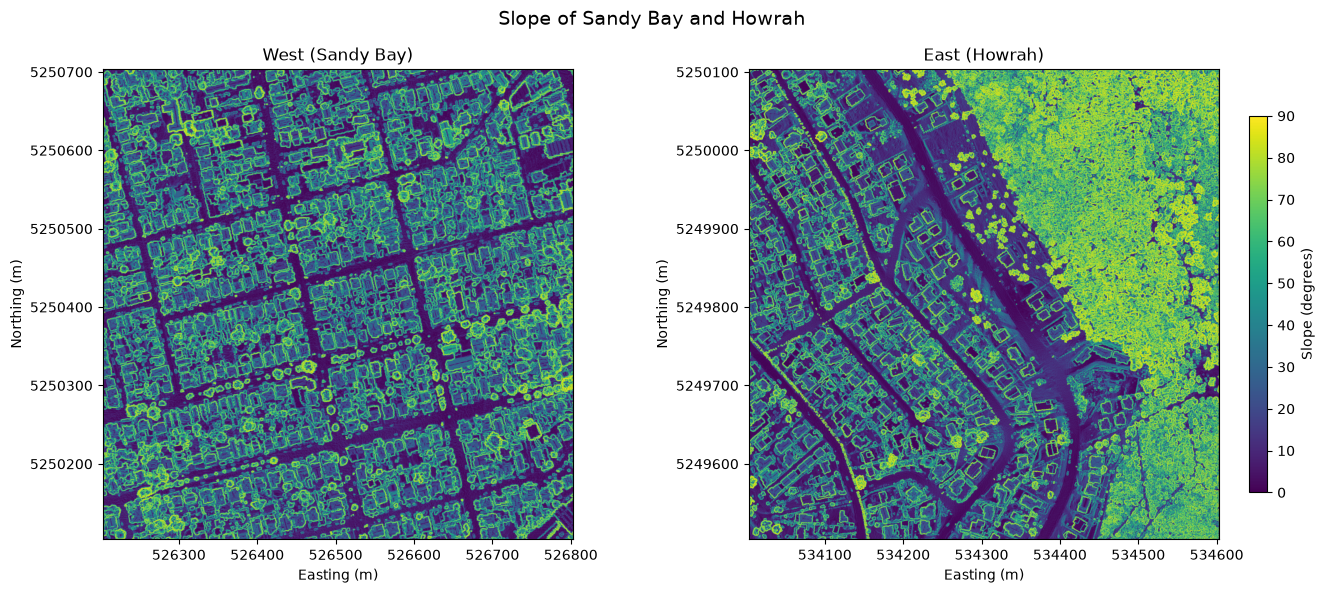

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# West (Sandy Bay)
west_slope_plot = axes[0].imshow(west_slope_degrees, cmap="viridis", vmin=0, vmax=90, extent=west_extent)
axes[0].set_title("West (Sandy Bay)")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
axes[0].ticklabel_format(style="plain", useOffset=False)  # show full coordinates instead of scientific notation

# East (Howrah)
east_slope_plot = axes[1].imshow(east_slope_degrees, cmap="viridis", vmin=0, vmax=90, extent=east_extent)
axes[1].set_title("East (Howrah)")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].ticklabel_format(style="plain", useOffset=False)
fig.colorbar(east_slope_plot, ax=axes[1], label="Slope (degrees)", shrink=0.8)

fig.suptitle("Slope of Sandy Bay and Howrah", fontsize=14)
plt.tight_layout()
fig.savefig("Images/slope.png", dpi=200, bbox_inches="tight")
plt.show()

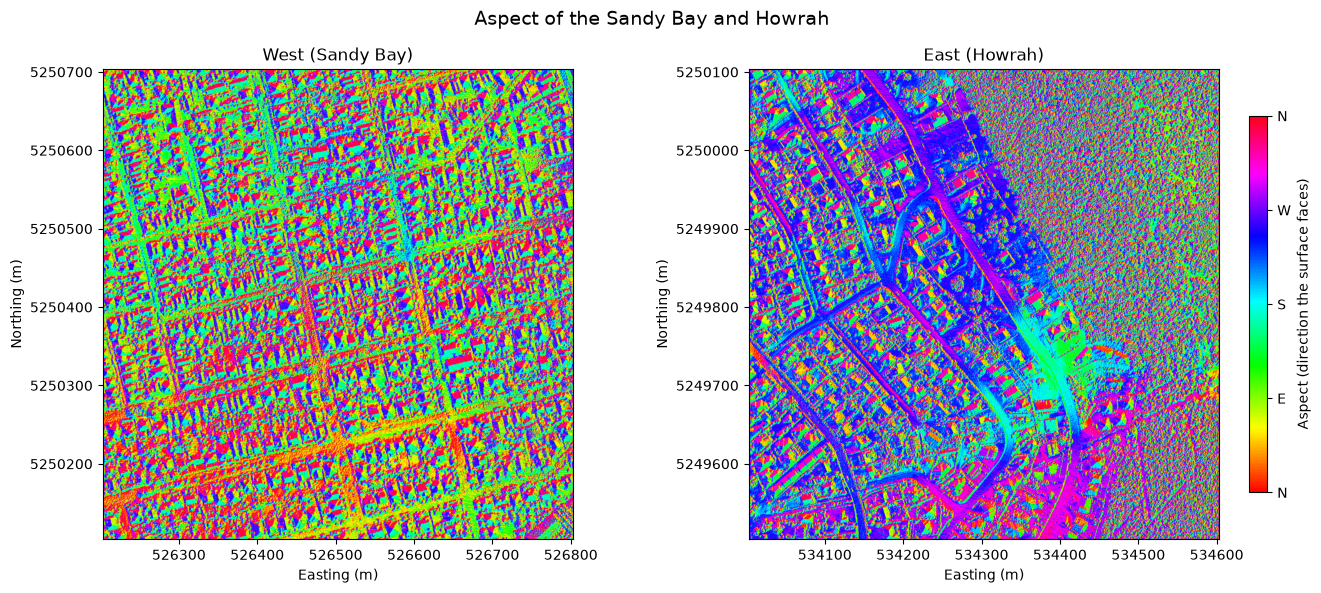

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# We use a circular colour scheme, because 0 and 360 are both north and should be the same colour
# West (Sandy Bay)
west_aspect_plot = axes[0].imshow(west_aspect_degrees, cmap="hsv", vmin=0, vmax=360, extent=west_extent)
axes[0].set_title("West (Sandy Bay)")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
axes[0].ticklabel_format(style="plain", useOffset=False)

# East (Howrah)
east_aspect_plot = axes[1].imshow(east_aspect_degrees, cmap="hsv", vmin=0, vmax=360, extent=east_extent)
axes[1].set_title("East (Howrah)")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].ticklabel_format(style="plain", useOffset=False)
east_aspect_bar = fig.colorbar(east_aspect_plot, ax=axes[1], label="Aspect (direction the surface faces)", shrink=0.8)
east_aspect_bar.set_ticks([0, 90, 180, 270, 360])
east_aspect_bar.set_ticklabels(["N", "E", "S", "W", "N"])

fig.suptitle("Aspect of the Sandy Bay and Howrah", fontsize=14)
plt.tight_layout()
fig.savefig("Images/aspect.png", dpi=200, bbox_inches="tight")
plt.show()

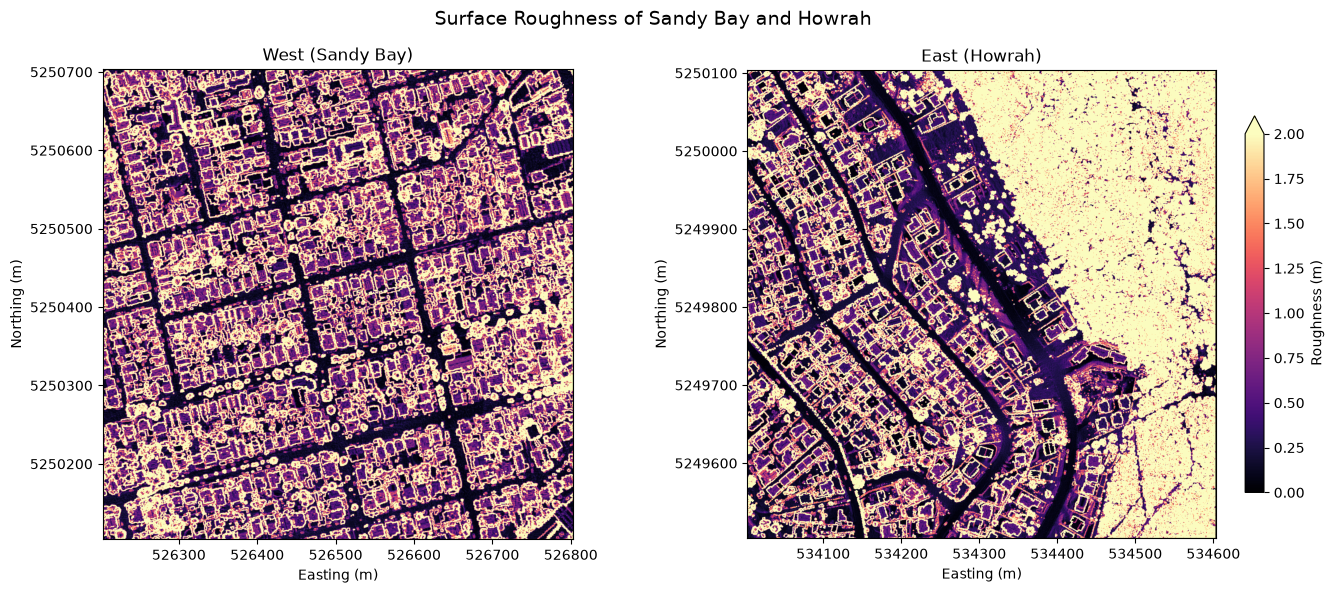

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# West (Sandy Bay)
west_roughness_plot = axes[0].imshow(west_roughness, cmap="magma", vmin=0, vmax=2, extent=west_extent)
axes[0].set_title("West (Sandy Bay)")
axes[0].set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
axes[0].ticklabel_format(style="plain", useOffset=False)

# East (Howrah)
east_roughness_plot = axes[1].imshow(east_roughness, cmap="magma", vmin=0, vmax=2, extent=east_extent)
axes[1].set_title("East (Howrah)")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].ticklabel_format(style="plain", useOffset=False)
fig.colorbar(east_roughness_plot, ax=axes[1], label="Roughness (m)", shrink=0.8, extend="max")

fig.suptitle("Surface Roughness of Sandy Bay and Howrah", fontsize=14)
plt.tight_layout()
fig.savefig("Images/roughness.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Weather and Sun Position

Read in the hourly weather file for Hobart Ellerslie Road. It covers one typical year (8,760 hours) and gives three sunlight values for each hour: GHI, DNI and DHI. Then use pvlib to work out where the sun is in the sky for each of those hours.

In [28]:
import pandas as pd
import pvlib

# Find the EPW file in the weather folder
weather_folder = inpath / "Ellerslie_Road_TMY"
epw_path = list(weather_folder.glob("*.epw"))[0]
print("File:", epw_path.name)

# read_epw gives back two things: the hourly table, and the details about the weather station
weather, station = pvlib.iotools.read_epw(weather_folder / epw_path.name)

# The location of the weather station, which we use for the sun position
latitude = station["latitude"]
longitude = station["longitude"]

# The three sunlight columns, each one a list of 8,760 hourly values in W/m²
ghi = weather["ghi"].values   # all sunlight on flat ground
dni = weather["dni"].values   # sunlight straight from the sun
dhi = weather["dhi"].values   # sunlight scattered by the sky and clouds

print("Number of hours:", len(weather))
print("Latitude and longitude:", latitude, longitude)
print("Yearly GHI in kWh/m²:", ghi.sum() / 1000)

File: AUS_TAS_Hobart.Ellerslie.Road.949700_TMYx.epw
Number of hours: 8760
Latitude and longitude: -42.8899 147.3276
Yearly GHI in kWh/m²: 1424.273


Calculating the sun position

In [29]:
# Each row in the weather file covers a full hour, so we find the sun position at the middle of that hour
times = weather.index + pd.Timedelta(minutes=30)

sun = pvlib.solarposition.get_solarposition(times, latitude, longitude)

sun_altitude = sun["apparent_elevation"].values   # how high the sun is above the horizon, in degrees
sun_azimuth = sun["azimuth"].values               # the compass direction of the sun, in degrees from north

# The sun is only up when its altitude is above 0
daylight = sun_altitude > 0

print("Daylight hours in the year:", daylight.sum())

Daylight hours in the year: 4410


In [30]:
# Find the hour when the sun is highest in the whole year
highest = sun_altitude.argmax()

print("Time:", times[highest])
print("Altitude:", sun_altitude[highest])
print("Azimuth:", sun_azimuth[highest])

Time: 2022-12-25 12:30:00+10:00
Altitude: 70.10070479282923
Azimuth: 346.76767854906427


## 4. Shadows

A pixel only gets direct sunlight if nothing taller sits between it and the sun.

## 5. Sunlight on each Pixel

## 6. Building Map